In [1]:
import sys

from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

from config import *

from Models.Papers import Amodeo2021

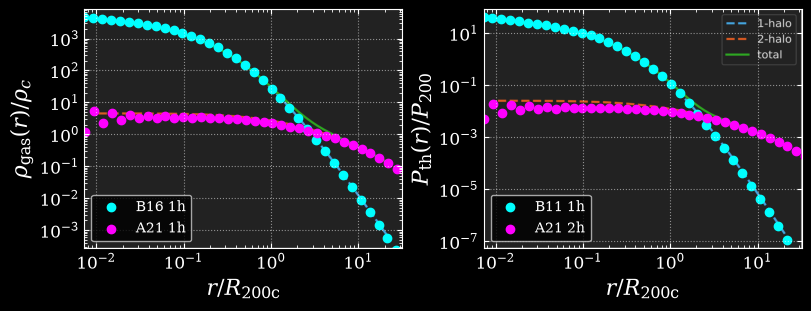

In [2]:
importlib.reload(Amodeo2021)
fig, axs = Amodeo2021.Fig7().full()

from Models import HaloModels
from Models.Papers import Battaglia2012
from Models.Papers import Battaglia2016
importlib.reload(HaloModels); importlib.reload(Battaglia2012); importlib.reload(Battaglia2016)

r, z, logM200c = np.geomspace(1e-3, 1e2, 50)*u.Mpc, Amodeo2021.TargetData().zMed, np.round(Amodeo2021.TargetData().logMhMean, 1)

hmod = HaloModels.colossus_model(Amodeo2021.HaloProfile().info)
x = lambda z, logM200c: r*u.Mpc/hmod.rdel('200c')(z, logM200c)

B11 = Battaglia2012.HaloProfiles(rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))
B16 = Battaglia2016.HaloProfiles({'model':'AGN'}, rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))

ptypo = {'beta_A0': B16.p0['beta_A0']-2*B16.p0['gamma']}
axs[0].scatter(x(z, logM200c), (B16.Density(r, z, logM200c)(ptypo)/B16.pc(z))[:, 0, 0], c='cyan', label='B16 1h')
axs[1].scatter(x(z, logM200c), (B11.Pressure(r, z, logM200c)()/B11.P200c(z, logM200c))[:, 0, 0], c='cyan', label='B11 1h')

hmod = HaloModels.pyccl_model(Amodeo2021.HaloProfile().info,PowSpec='LINEAR', Concentration='constant')
A21 = Amodeo2021.HaloProfile({'model':'GNFW'},rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), dndlogm=hmod.dndlogm, bh=hmod.bh, Plin=hmod.Plin)

axs[0].scatter(x(z, logM200c), (A21.Density2h(r, z, logM200c)/A21.pc(z))[:, 0, 0], c='magenta', label='A21 1h')
axs[1].scatter(x(z, logM200c), (A21.Pressure2h(r, z, logM200c)/A21.P200c(z, logM200c))[:, 0, 0], c='magenta', label='A21 2h')

# dndlogm2 = lambda z, logm: hmod.dndlogm(z, hmod.logM_conv(z, logm, 'fof')-np.log10(hmod.params['h']))*hmod.params['h']**4
# bh2 = lambda z, logm: hmod.bh(z, logm-np.log10(hmod.params['h']))
# Plin2 = lambda k, z: hmod.Plin(k*hmod.params['h'], z)/hmod.params['h']**3
# M21 = Profiles.Moser2021({'model':'GNFW'},rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), dndlogm=dndlogm2, bh=bh2, Plin=Plin2)

axs[0].legend(loc='lower left'); axs[1].legend(loc='lower left')
plt.show()

/tmp/ipykernel_3956972/3808003046.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend(); axs[1].legend()


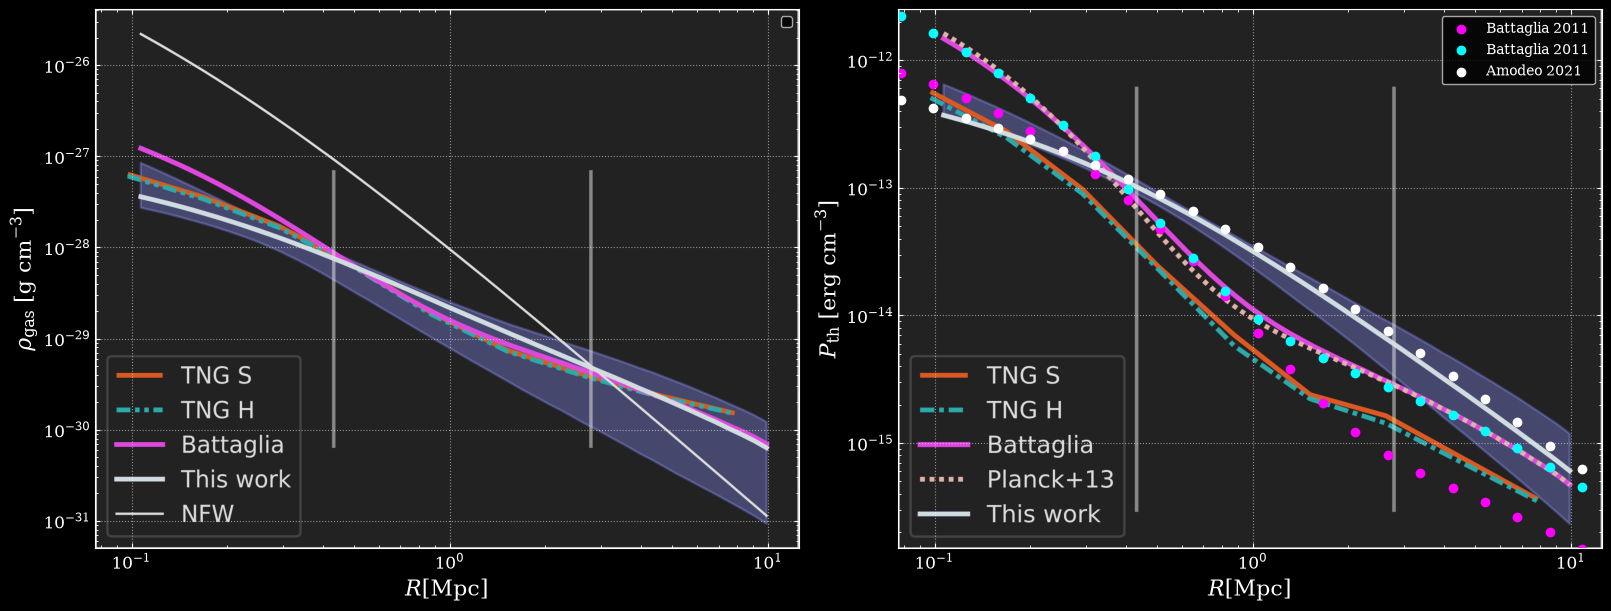

In [3]:
importlib.reload(Amodeo2021)
fig, axs = Amodeo2021.Fig6().row(0)


r, z, logM200c = np.geomspace(1e-3, 1e2, 50), Amodeo2021.TargetData().zMed, np.round(Amodeo2021.TargetData().logMhMean, 1)

hmod = HaloModels.colossus_model(Amodeo2021.HaloProfile().info)
x = lambda z, logM200c: r*u.Mpc/hmod.rdel('200c')(z, logM200c)

b_cen = np.array([12.27689266, 12.67884686, 13.16053855, 13.69871423])
p = np.array([4.13431979e-03, 1.31666601e-01, 3.36540698e-01, 8.13760167e-02])
weight = lambda prof: np.average(prof(b_cen), weights=p, axis=-1)[:, 0]

B11 = Battaglia2012.HaloProfiles(rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))
B16 = Battaglia2016.HaloProfiles({'model':'AGN'}, rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))

hmod = HaloModels.pyccl_model(Amodeo2021.HaloProfile().info,PowSpec='LINEAR', Concentration='constant')
A21 = Amodeo2021.HaloProfile({'model':'GNFW'},rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), dndlogm=hmod.dndlogm, bh=hmod.bh, Plin=hmod.Plin)

# ptypo = {'beta_A0': B16.p0['beta_A0']-2*B16.p0['gamma']}
# func = lambda logM200c: B16.Density(r, z, logM200c, units='cgs')(ptypo)+A21.Density2h(r, z, logM200c, units='cgs')
# axs[0].scatter(x(z, logM200c), weight(func), marker='o', c='magenta', label='Battaglia 2016')

func = lambda logM200c: B11.Pressure(r, z, logM200c, units='cgs')(ptypo)+A21.Pressure2h(r, z, logM200c, units='cgs')
axs[1].scatter(x(z, logM200c), weight(func)/5, marker='o', c='magenta', label='Battaglia 2011')


func = lambda logM200c: B11.Pressure(r/0.7**(5/3), z, logM200c, units='cgs')(ptypo)+A21.Pressure2h(r/0.7**(5/3), z, logM200c, units='cgs')/0.7
axs[1].scatter(x(z, logM200c), weight(func), marker='o', c='cyan', label='Battaglia 2011')


# func = lambda logM200c: A21.Density(r, z, logM200c, units='cgs')()
# axs[0].scatter(x(z, logM200c), weight(func), marker='o', c='w', label='Amodeo 2021')

func = lambda logM200c: A21.Pressure(r, z, logM200c, units='cgs')()
axs[1].scatter(x(z, logM200c), weight(func)/2, marker='o', c='w', label='Amodeo 2021')


axs[0].legend(); axs[1].legend()
plt.show()

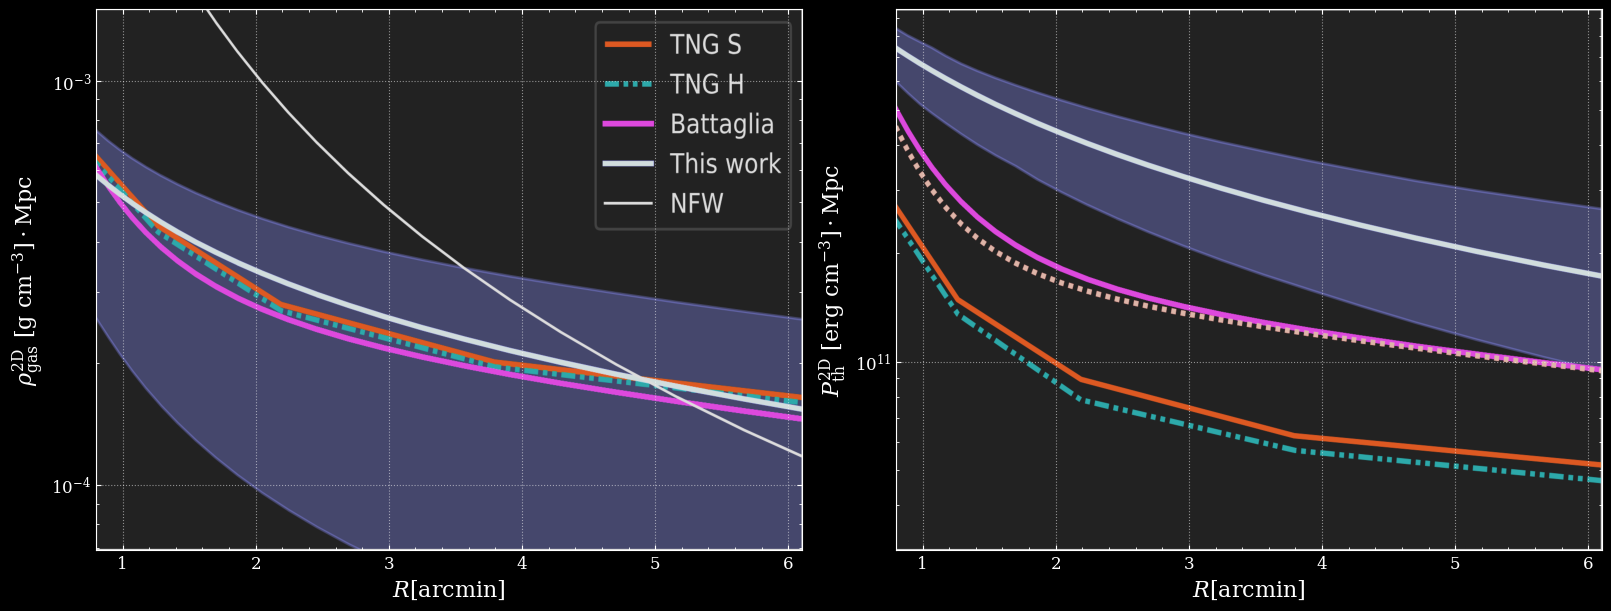

In [3]:
importlib.reload(Amodeo2021)

fig, axs = Amodeo2021.Fig6().row(1)

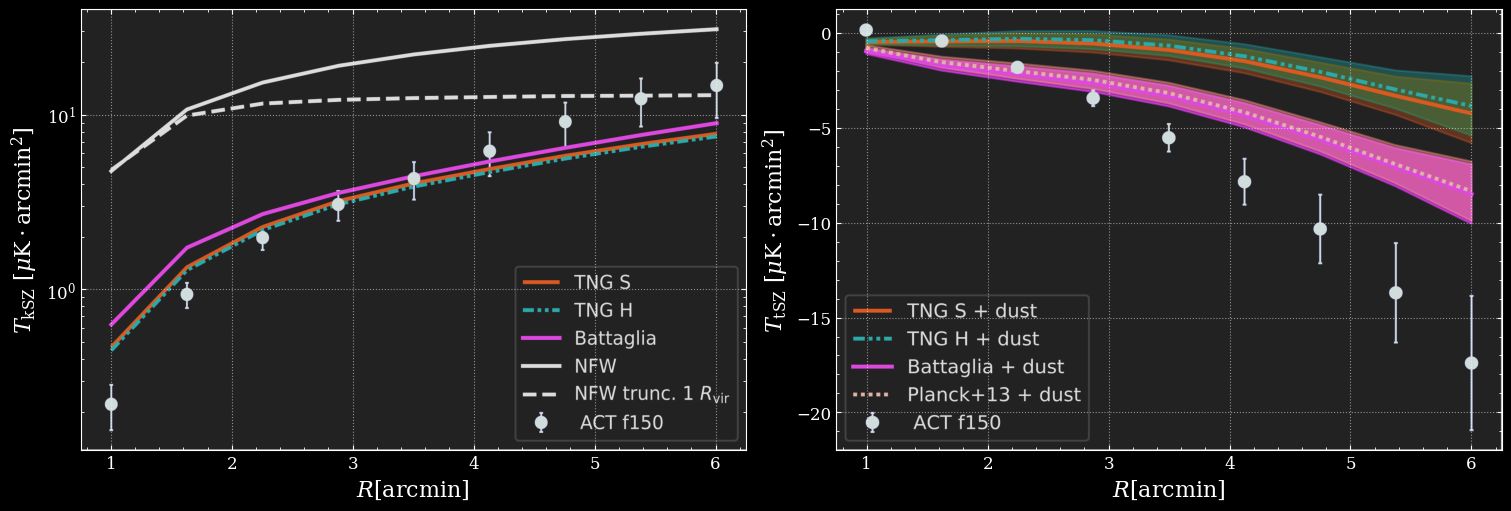

In [4]:
importlib.reload(Amodeo2021)

fig, axs = Amodeo2021.Fig6().row(2)

In [ ]:
importlib.reload(Amodeo2021)
fig, axs = Amodeo2021.Fig11().row(0)

AmodeoDustHr = Amodeo2021.Dust({'fitdata':'Hr'})
AmodeoDustAHr = Amodeo2021.Dust({'fitdata':'ACTHr'})
nu = lambda L: (c.c/(L*u.um)).to(u.GHz)

Rs = np.linspace(1.5, 6, 10)

axs[0].scatter(Rs, AmodeoDustHr.dustpoly(Rs, nu(500))(), lw=3, c='magenta', alpha=0.5, ls='--', label='mine')
axs[0].scatter(Rs, AmodeoDustAHr.dustpoly(Rs, nu(500))(), lw=3, c='lime', alpha=0.5, ls='--', label='mine')

axs[1].scatter(Rs, AmodeoDustHr.dustpoly(Rs, nu(350))(), lw=3, c='magenta', alpha=0.5, ls='--', label='mine')
axs[1].scatter(Rs, AmodeoDustAHr.dustpoly(Rs, nu(350))(), lw=3, c='lime', alpha=0.5, ls='--',label='mine')

axs[2].scatter(Rs, AmodeoDustHr.dustpoly(Rs, nu(250))(), lw=3, c='magenta', alpha=0.5, ls='--', label='mine')
axs[2].scatter(Rs, AmodeoDustAHr.dustpoly(Rs, nu(250))(), lw=3, c='lime', alpha=0.5, ls='--', label='mine')

axs[0].legend(); axs[1].legend(); axs[2].legend()

plt.show()

In [ ]:
importlib.reload(Amodeo2021)
fig, axs = Amodeo2021.Fig11().row(1)

AmodeoDustHr = Amodeo2021.Dust({'fitdata':'Hr'})
AmodeoDustAHr = Amodeo2021.Dust({'fitdata':'ACTHr'})
Rs = np.linspace(1.5, 6, 10)

axs[0].scatter(Rs, AmodeoDustAHr.dust_uKarcmin(Rs, 150*u.GHz)(), lw=3, c='lime', alpha=0.5, label='mine')

axs[1].scatter(Rs, AmodeoDustAHr.dust_uKarcmin(Rs, 90*u.GHz)(), lw=3, c='lime', alpha=0.5,label='mine')

axs[0].legend(); axs[1].legend()
plt.show()